# Matplotlib 차트 유형별 시각화
Matplotlib에서 자주 사용하는 차트 유형을 정리한다.

- 데이터 형태에 따라 적절한 차트를 고를 수 있다.
- Histogram, Bar Plot, Line Plot, Scatter Plot, Pie Chart, Box Plot의 용도를 설명할 수 있다.
- 그래프 옵션을 직접 수정할 수 있다.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Windows 기준 한글 폰트 설정
plt.rc('font', family='Malgun Gothic')
# 마이너스 부호가 깨지는 문제 방지
plt.rc('axes', unicode_minus=False)

## 1. Histogram
- 연속형 데이터의 분포를 구간별 빈도수로 확인할 때 사용한다. 
- 점수, 키, 몸무게처럼 '어느 구간에 많이 몰려 있는가'를 보고 싶을 때 적합하다.

count: [1. 2. 1. 3. 3. 3. 2. 5.]
bins: [60.   64.25 68.5  72.75 77.   81.25 85.5  89.75 94.  ]
container: <BarContainer object of 8 artists>
60.0 ~ 64.25: 1개
64.25 ~ 68.5: 2개
68.5 ~ 72.75: 1개
72.75 ~ 77.0: 3개
77.0 ~ 81.25: 3개
81.25 ~ 85.5: 3개
85.5 ~ 89.75: 2개
89.75 ~ 94.0: 5개


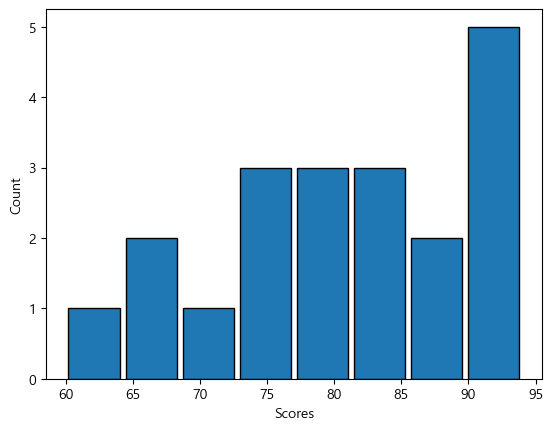

In [3]:
# 시험 성적 데이터 (0~100 점)
scores = [88, 90, 77, 65, 80, 85, 92, 78, 75, 82, 94, 91, 60, 73, 86, 82, 93, 72, 75, 68]

# 히스토그램 생성
count, bins, container = plt.hist(
    scores,
    bins=8,            # 구간 개수 (막대 개수)
    edgecolor='k',     # 막대 테두리 색 ('k' = black)
    rwidth=.9          # 막대 너비 (0~1, 값이 작을수록 간격 생김)
)

# 반환값 확인
print('count:', count)       # 각 구간별 데이터 개수
print('bins:', bins)         # 구간 경계 값 (길이 = bins+1)
print('container:', container)  # 그래프 객체 (막대 정보)

# 각 구간별 범위와 개수 출력
for i in range(8):
    print(f'{bins[i]} ~ {bins[i + 1]}: {int(count[i])}개')
    # bins[i] 이상 ~ bins[i+1] 미만 구간에 count[i]개의 데이터 존재

# 축 이름 설정
plt.xlabel('Scores')  # x축: 점수 구간
plt.ylabel('Count')   # y축: 개수(빈도)

# 그래프 출력
plt.show()

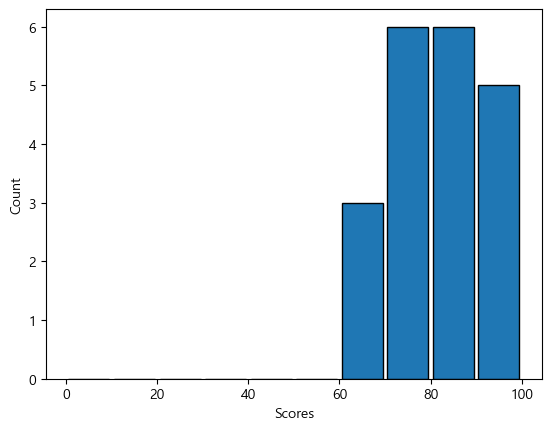

In [4]:
# 사용자 지정 bins
# 자동 bins/라이브러리가 임의로 구간을 나눈다면, 구간이 불균등하게 나뉘거나 원하는 구간이 아닐 수 있다.
scores = [88, 90, 77, 65, 80, 85, 92, 78, 75, 82, 94, 91, 60, 73, 86, 82, 93, 72, 75, 68]

# 0~100 구간을 10등분 => [0,10), [10,20), ..., [90,100]
bins = np.linspace(0, 100, 11)  
# linspace(start, end, 개수)
# 0부터 100까지 "11개의 경계값" 생성 (즉, 구간은 10개)

# 히스토그램 생성 (직접 정의한 bins 사용)
plt.hist(
    scores,
    bins=bins,        
    edgecolor='k',    
    rwidth=.9         
)

# 축 이름 설정
plt.xlabel('Scores')
plt.ylabel('Count')

# 그래프 출력
plt.show()

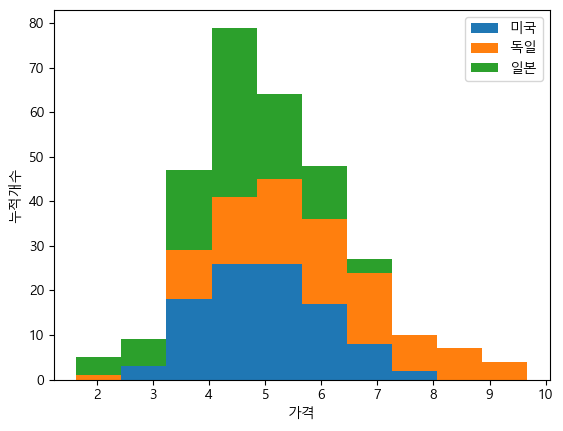

In [6]:
# 복수개의 히스토그램

# 국가별 맥주 가격 데이터 생성 (정규분포 기반 랜덤 데이터)
us_beer_price = np.random.normal(5, 1, 100)   # 평균 5, 표준편차 1 (미국)
ge_beer_price = np.random.normal(6, 1.5, 100) # 평균 6, 표준편차 1.5 (독일)
jp_beer_price = np.random.normal(4.5, 1, 100) # 평균 4.5, 표준편차 1 (일본)

# 여러 데이터셋을 한 번에 히스토그램으로 그리기
plt.hist(
    [us_beer_price, ge_beer_price, jp_beer_price],  # 리스트 형태로 여러 데이터 전달
    label=['미국', "독일", "일본"],                  # 각 데이터에 대한 범례 이름
    stacked=True                                    # True: 누적 히스토그램 (쌓아서 표현)
    # stacked=False: 겹쳐서 비교 (기본값)
)

# 범례 표시
plt.legend()

# 축 이름
plt.xlabel('가격')        # x축: 가격 구간
plt.ylabel('누적개수')    # y축: 누적된 데이터 개수

# 그래프 출력
plt.show()

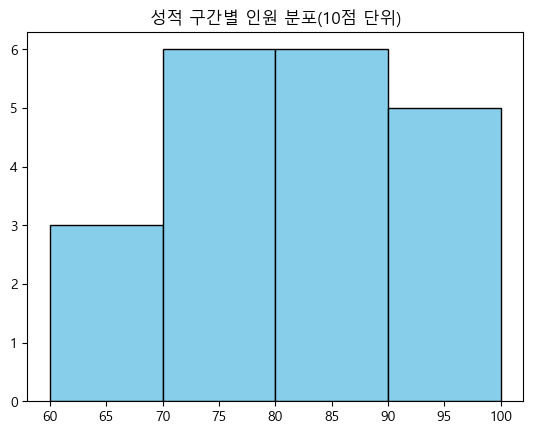

In [8]:
# TODO - Histogram
# scores 데이터를 이용해 60점부터 100점까지 10점 간격으로 히스토그램을 그려보세요.
# 조건: 1) bins를 [60, 70, 80, 90, 100]으로 직접 지정 2) 막대 색상을 'skyblue'로 변경 3) 제목 설정
bins_list = [60, 70, 80, 90, 100]
plt.hist(scores, bins=bins_list, color='skyblue',edgecolor='black')
plt.title("성적 구간별 인원 분포(10점 단위)")
plt.show()

## 2. Bar Plot
- 이산형 데이터에 대한 수치값(빈도수, 수치)을 막대의 길이로 표현하는 그래프
- 범주형 데이터의 크기를 비교할 때 사용한다. 
- 제품별 판매량, 부서별 인원 수처럼 카테고리 간 비교가 핵심일 때 적합하다.

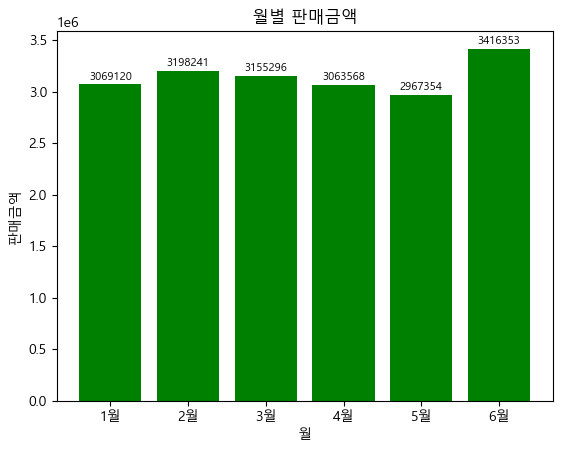

In [9]:
# 월별 판매 데이터
months = ['1월', '2월', '3월', '4월', '5월', '6월']  # x축 (범주형 데이터)
sales = np.random.normal(3_000_000, 500_000, 6).astype(int)
# 평균 300만, 표준편차 50만의 6개 데이터 생성 (정수형 변환)

# 막대 그래프 생성
plt.bar(
    months, sales,
    color='g'   # 색상: 'g'(green), 'b', 'r', 'orange' ...
)

# 제목 및 축 이름
plt.title('월별 판매금액')
plt.xlabel('월')
plt.ylabel('판매금액')

# 막대 위에 값 표시 (텍스트 추가)
for i, money in enumerate(sales):
    # i는 x축 위치 (인덱스)
    # money는 해당 막대의 값 (높이)

    plt.text(
        i, money + 50000,   # (x좌표, y좌표)를 막대 위에 약간 띄워서 표시
        str(money),         # 표시할 텍스트 (숫자를 문자열 변환)
        fontsize=8,         # 글자 크기
        ha='center'         # 가로 정렬 ('left', 'center', 'right')
    )

# 그래프 출력
plt.show()

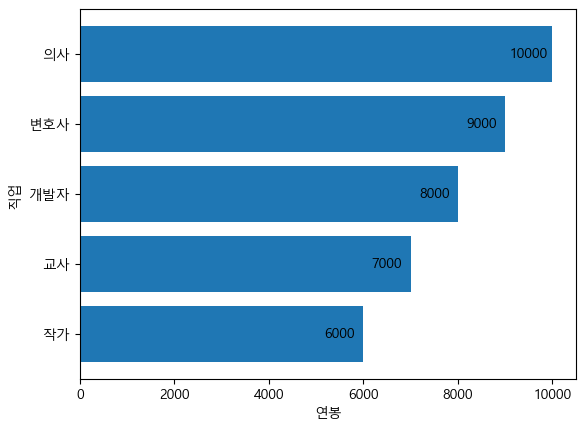

In [10]:
# 정렬이 효과적인 경우 (값의 크기 비교를 직관적으로 하기 위해 정렬)
job_df = pd.DataFrame([
    ('개발자', 8000),
    ('의사', 10000),
    ('교사', 7000),
    ('작가', 6000),
    ('변호사', 9000),
], columns=['직업', '연봉']).sort_values('연봉', ascending=True)
# 연봉 기준 오름차순 정렬하여 작은 값에서 큰 값 순서
# 막대 길이 증가 흐름이 한눈에 보이게 함

# 가로 막대 그래프 (barh)
plt.barh(
    job_df['직업'],   # y축: 직업 (카테고리)
    job_df['연봉']    # x축: 연봉 (값)
)

# 축 이름
plt.xlabel('연봉')
plt.ylabel('직업')

# 막대 안에 값 표시
for i, data in enumerate(job_df['연봉']):
    # i는 y축 위치 (인덱스)
    # data는 연봉 값 (막대 길이)

    plt.text(
        data - 500,     # x좌표 (막대 안쪽으로 조금 이동)
        i,              # y좌표 (해당 막대 위치)
        str(data),      # 표시할 텍스트
        ha='center',    # 가로 정렬
        va='center'     # 세로 정렬
    )

# 그래프 출력
plt.show()

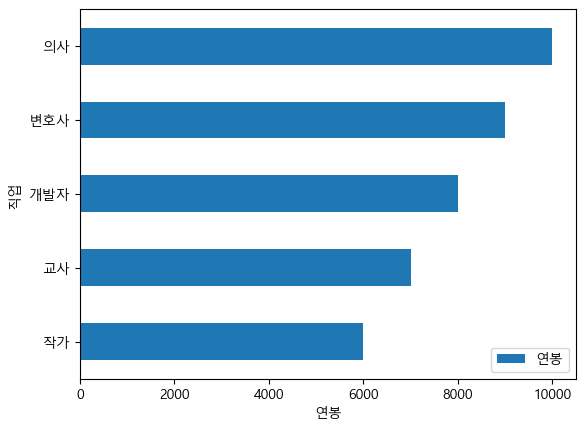

In [11]:
# pandas DataFrame객체 제공 plot메소드
job_df = pd.DataFrame([
    ('개발자', 8000),
    ('의사', 10000),
    ('교사', 7000),
    ('작가', 6000),
    ('변호사', 9000),
], columns=['직업', '연봉']).sort_values('연봉', ascending=True)

# job_df.plot(kind='barh', x='직업', y='연봉')
job_df.set_index('직업').plot(kind='barh')

plt.xlabel('연봉')
plt.ylabel('직업')

plt.show()

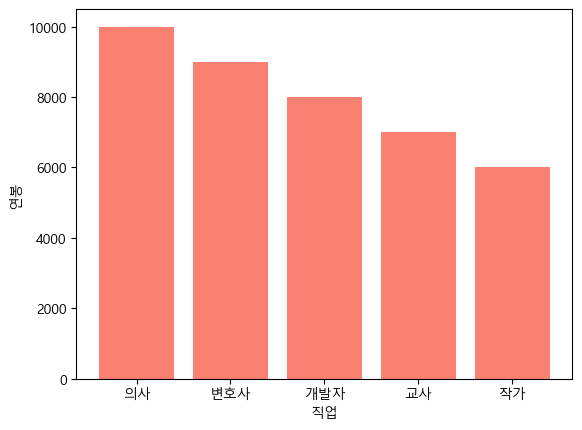

In [12]:
# TODO - Bar Plot
# job_df를 이용해 연봉이 '높은 순'으로 정렬된 세로 막대 그래프를 그려보세요.
# 조건: 1) 연봉 기준 내림차순 정렬 2) 막대 색상을 'salmon'으로 지정 3) 축 이름 설정
job_sorted = job_df.sort_values('연봉', ascending=False)
plt.bar(job_sorted['직업'], job_sorted['연봉'], color='salmon')
plt.xlabel('직업')
plt.ylabel('연봉')
plt.show()

## 3. Line Plot
- 시간 흐름이나 순서가 있는 데이터의 변화 추이를 볼 때 사용한다. 
- 월별 매출, 일별 방문자 수, 가격 추세 시각화에 적합하다.

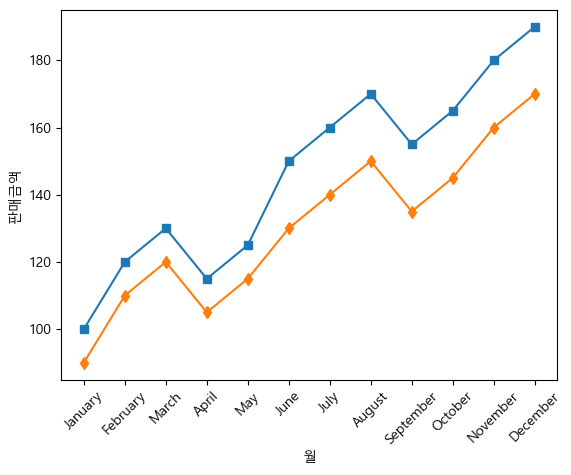

In [13]:
# 월별 판매데이터
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
sales = [100, 120, 130, 115, 125, 150, 160, 170, 155, 165, 180, 190]
sales2 = [90, 110, 120, 105, 115, 130, 140, 150, 135, 145, 160, 170]

plt.plot(months, sales, marker='s')
plt.plot(months, sales2, marker='d')

plt.xlabel('월')
plt.ylabel('판매금액')
plt.xticks(rotation=45)
plt.show()

In [17]:
# 암호화폐 가격 추이 시각화
# - 비트코인
# - 이더리움

crypto_df = pd.read_csv('data/crypto_daily_prices.csv')
# 날짜형 변환
crypto_df['Date'] = pd.to_datetime(crypto_df['Date'])
crypto_df.tail(10)

,Date,BTC-USD Price,ETH-USD Price,LTC-USD Price
2375,2021-03-23,54738.94531,1678.650146,187.393967
2376,2021-03-24,52774.26563,1593.413452,177.654953
2377,2021-03-25,51704.16016,1595.359253,173.061188
2378,2021-03-26,55137.31250,1702.842041,184.278671
2379,2021-03-27,55973.51172,1716.494629,184.830444
2380,2021-03-28,55950.74609,1691.355957,185.028488
2381,2021-03-29,57750.19922,1819.684937,194.474777
2382,2021-03-30,58917.69141,1846.033691,196.682098
2383,2021-03-31,58918.83203,1918.362061,197.499100
2384,2021-04-01,59095.80859,1977.276855,204.112518


In [16]:
crypto_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2385 entries, 0 to 2384
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           2385 non-null   datetime64[us]
 1   BTC-USD Price  2385 non-null   float64       
 2   ETH-USD Price  2061 non-null   float64       
 3   LTC-USD Price  2385 non-null   float64       
dtypes: datetime64[us](1), float64(3)
memory usage: 74.7 KB


In [18]:
crypto_df.describe()

,Date,BTC-USD Price,ETH-USD Price,LTC-USD Price
count,2385,2385.000000,2061.000000,2385.000000
mean,2017-12-22 08:38:02.264151,6471.857333,281.507678,50.907238
min,2014-09-17 00:00:00,178.102997,0.434829,1.157010
25%,2016-05-05 00:00:00,454.618988,13.035700,3.826380
50%,2017-12-22 00:00:00,4076.632568,187.325317,43.022701
75%,2019-08-10 00:00:00,8864.766602,346.532654,68.170303
max,2021-04-01 00:00:00,61243.085940,1977.276855,358.335999
std,NaN,9289.022505,359.038596,57.699041


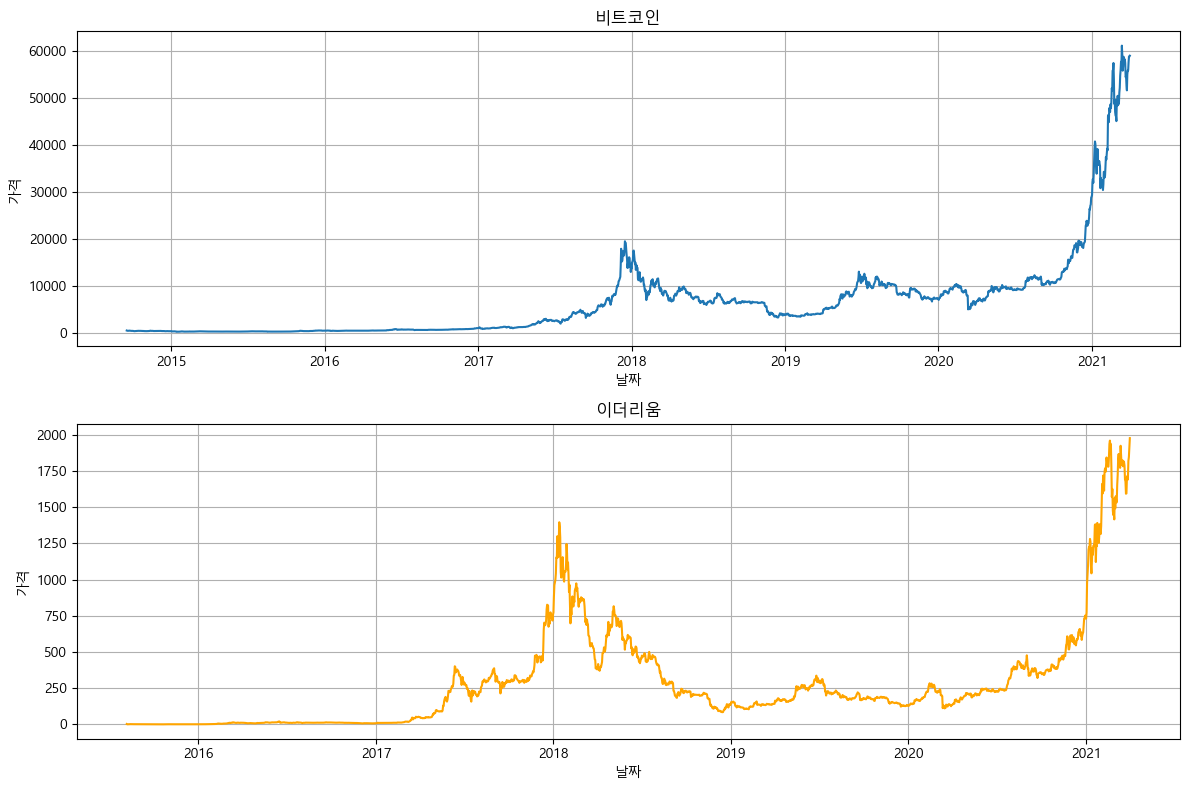

In [19]:
# subplot을 이용해서 ax1, ax2에 각각 라인플롯 그리기
# - ax 두개 만들기
# - ax1에 비트코인 라인플롯 그리기 (x축=날짜, y축=가격)
# - ax2에 이더리움 라인플롯 그리기 (x축=날짜, y축=가격)

# ax 두개 만들기
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# 비트코인
ax[0].plot(crypto_df['Date'], crypto_df['BTC-USD Price'])
ax[0].set_title('비트코인')
ax[0].set_xlabel('날짜')
ax[0].set_ylabel('가격')
ax[0].grid()

# 이더리움
ax[1].plot(crypto_df['Date'], crypto_df['ETH-USD Price'], color='orange')
ax[1].set_title('이더리움')
ax[1].set_xlabel('날짜')
ax[1].set_ylabel('가격')
ax[1].grid()

plt.tight_layout() # ax간격 자동조정
plt.show()

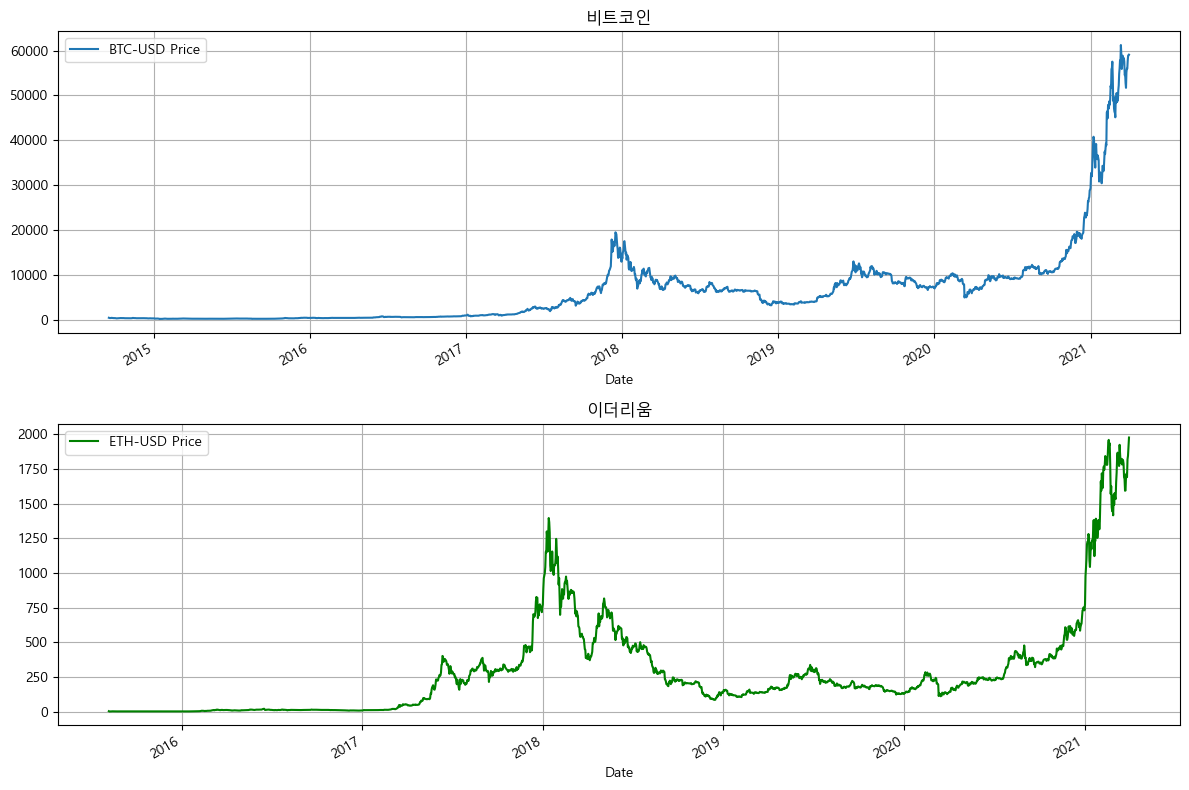

In [20]:
# dataframe 기준으로 plot그리기

# ax 두개 만들기
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

# 비트코인
crypto_df.plot(x='Date', y='BTC-USD Price', ax=ax[0])
ax[0].set_title('비트코인')
ax[0].grid()

# 이터리움
crypto_df.plot(x='Date', y='ETH-USD Price', ax=ax[1], color="green")
ax[1].set_title('이더리움')
ax[1].grid()

plt.tight_layout() # ax간격 자동조정
plt.show()

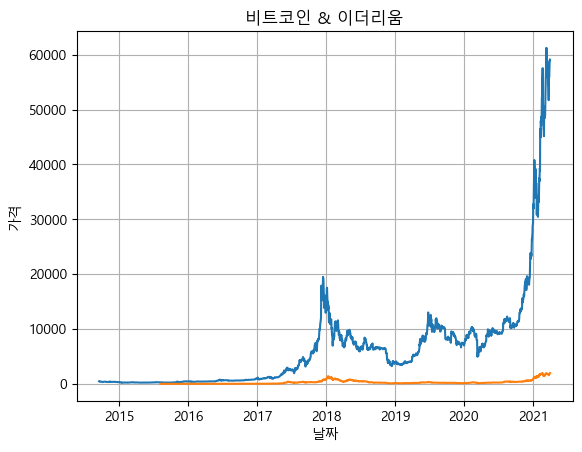

In [21]:
# 두개의 라인플롯 하나의 ax에 그리기
plt.plot(crypto_df['Date'], crypto_df['BTC-USD Price'])
plt.plot(crypto_df['Date'], crypto_df['ETH-USD Price'])

plt.title('비트코인 & 이더리움')
plt.xlabel('날짜')
plt.ylabel('가격')
plt.grid()

plt.show()

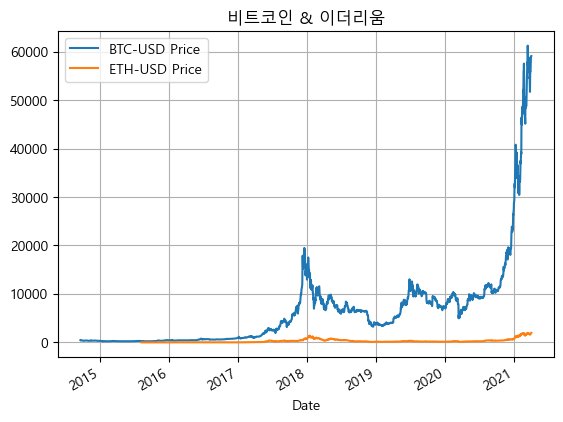

In [22]:
# DataFrame 기준
crypto_df.plot(x='Date', y=['BTC-USD Price', 'ETH-USD Price'])

plt.title('비트코인 & 이더리움')
plt.grid()

plt.show()

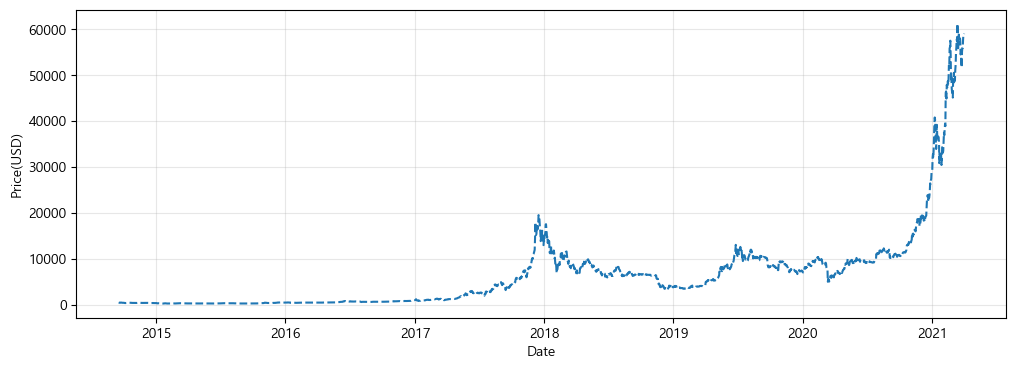

In [24]:
# TODO - Line Plot
# crypto_df를 이용해 BTC-USD Price의 추이를 그려보세요.
# 조건: 1) 선 스타일을 점선('--')으로 설정 2) 마커는 생략하거나 '.'으로 작게 표시 
#      3) grid를 배경에 깔기 4) y축 라벨을 'Price (USD)'로 설정

plt.figure(figsize=(12,4))
plt.plot(crypto_df['Date'], crypto_df['BTC-USD Price'], linestyle='--')
plt.grid(True, alpha=0.3)   # alpha : 투명도
plt.ylabel("Price(USD)")
plt.xlabel("Date")
plt.show()

## 4. Scatter Plot
- 두 개의 연속형 변수 관계를 점으로 표현한다. 
- 상관관계, 군집, 이상치 여부를 빠르게 볼 때 유용하다.

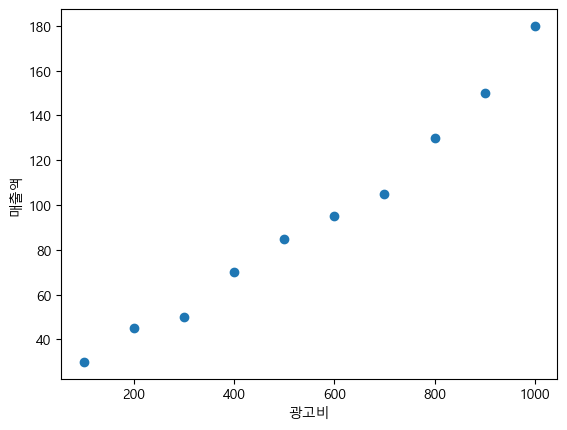

In [25]:
# 광고비와 판매량 데이터
ad_budget = [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
sales = [30, 45, 50, 70, 85, 95, 105, 130, 150, 180]

plt.scatter(ad_budget, sales)

plt.xlabel('광고비')
plt.ylabel('매출액')
plt.show()

In [26]:
# 타이타닉데이터 로그
titanic_df = pd.read_csv('data/titanic.csv')
titanic_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


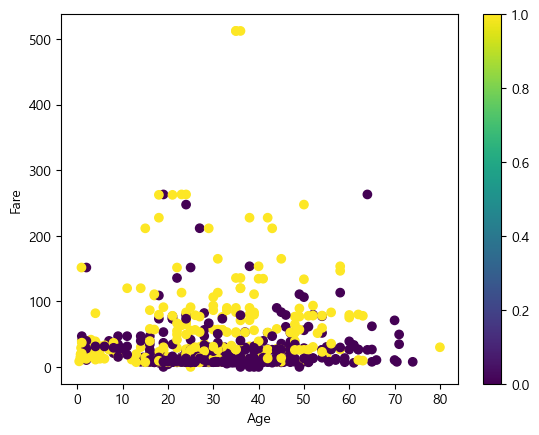

In [27]:
# c=색상 기준 값 (0/1에 따라 색이 달라짐)
plt.scatter(titanic_df['Age'], titanic_df['Fare'], c=titanic_df['Survived'])

plt.xlabel('Age')
plt.ylabel('Fare')

# colorbar: 색상 기준(컬러맵)을 시각적으로 보여줌
# c에 전달된 값(여기서는 Survived)의 범위를 표시
plt.colorbar()

plt.show()

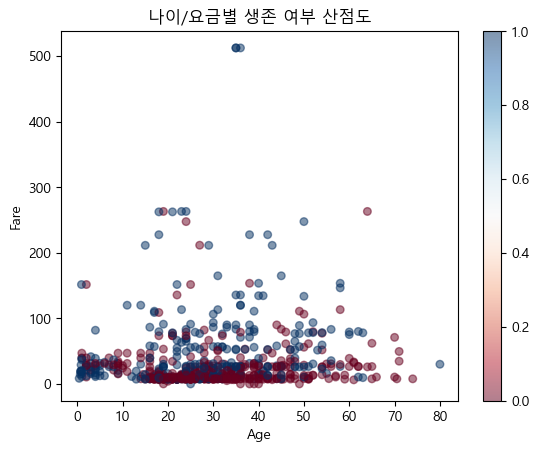

In [31]:
# TODO - Scatter Plot
# titanic_df를 이용해 나이(Age)와 요금(Fare)의 상관관계를 그려보세요.
# 조건: 1) 점의 크기(s)를 30으로 설정 2) 점의 투명도(alpha)를 0.5로 설정 (겹침 확인용)
#      3) 색상은 Survived 컬럼을 활용하고, 'RdBu' 컬러맵을 사용해보세요.
plt.scatter(titanic_df['Age'],
            titanic_df['Fare'],
            c=titanic_df['Survived'],
            s=30, 
            alpha=0.5, 
            cmap='RdBu')

plt.xlabel('Age')
plt.ylabel('Fare')

# colorbar: 색상 기준(컬러맵)을 시각적으로 보여줌
# c에 전달된 값(여기서는 Survived)의 범위를 표시
plt.title(label='나이/요금별 생존 여부 산점도')
plt.colorbar()

plt.show()

## 5. Pie Chart
- 전체 대비 비율이나 점유율을 강조할 때 사용한다. 
- 다만 범주가 많거나 수치 비교가 중요하면 막대그래프가 더 적합한 경우가 많다.

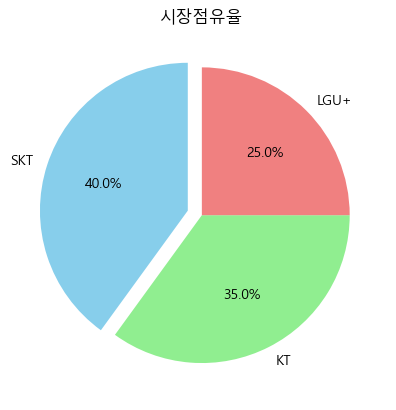

In [32]:
# 시장점유율
companies = ['SKT', 'KT', 'LGU+']
marcket_shares = [40, 35, 25] # 퍼센트 또는 수치값
explode = [0.1, 0, 0]   # explode: 각 조각을 중심에서 얼마나 떨어뜨릴지 (강조 효과)

plt.pie(marcket_shares, labels=companies,
        startangle=90,  # 시작 각도 (시계방향으로 90도 회전하여 시작)
        colors=['skyblue', 'lightgreen', 'lightcoral'],
        autopct='%1.1f%%',      # 퍼센트 표시 형식 (소수점 1자리까지)
        explode=explode,)       

plt.title('시장점유율')
plt.show()

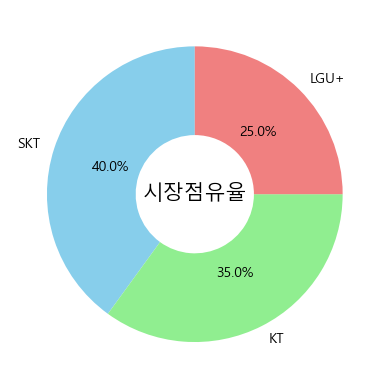

In [33]:
# 시장점유율 도넛챠트
companies = ['SKT', 'KT', 'LGU+']
market_shares = [40, 35, 25] # 퍼센트 또는 수치값

plt.pie(market_shares, labels=companies,
        startangle=90,
        colors=['skyblue', 'lightgreen', 'lightcoral'],
        autopct='%1.1f%%',
        wedgeprops={'width': 0.6})      # wedgeprops: 조각 속성 (width=0.6: 도넛 모양으로 만들기)

plt.text(0, 0, '시장점유율', ha='center', va='center', fontsize=15)
plt.show()

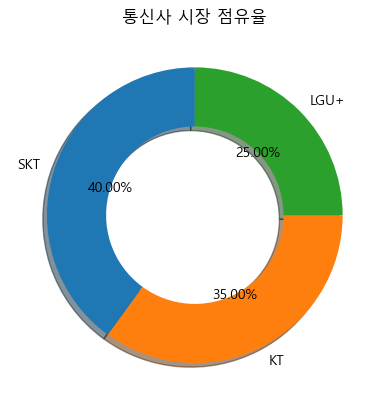

In [35]:
# TODO - Pie Chart
# market_shares를 이용해 입체감이 있는 도넛 차트를 그려보세요.
# 조건: 1) 12시 방향에서 시작 (startangle=90) 2) 그림자 효과 추가 (shadow=True)
#      3) 도넛의 두께를 더 얇게 조절 (width=0.4)
plt.pie(market_shares,
        labels=companies,
        autopct='%1.2f%%',
        startangle=90,
        shadow=True,
        wedgeprops={'width':0.4}
        )

plt.title('통신사 시장 점유율')
plt.show()

## 6. Box Plot
- 중앙값, 사분위수, 이상치를 함께 확인할 수 있다. 
- 여러 그룹의 분포를 비교할 때 아주 유용하다.

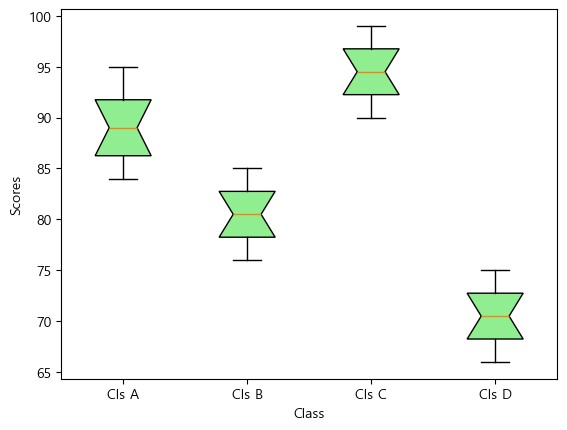

In [ ]:
# 각 반의 수학 시험 성적 (예시 데이터)
class_scores = [
    [85, 88, 90, 92, 93, 87, 95, 91, 84, 86],  # Class A
    [78, 82, 85, 80, 79, 84, 81, 83, 77, 76],  # Class B
    [92, 95, 96, 94, 90, 97, 93, 91, 98, 99],  # Class C
    [70, 72, 68, 75, 74, 69, 73, 71, 66, 67]   # Class D
]

plt.boxplot(class_scores,
            notch=True,                             # 노치(중앙값 주변 움푹 들어간 부분) 표시 여부
            patch_artist=True,                       # 박스 내부 색상 채우기 허용
            boxprops=dict(facecolor='lightgreen'))  # boxprops: 박스 속성 (facecolor: 박스 내부 색상)

plt.xlabel('Class')
plt.ylabel('Scores')

# ticks
plt.xticks([1, 2, 3, 4], ['Cls A', 'Cls B', 'Cls C', 'Cls D'])

plt.show()

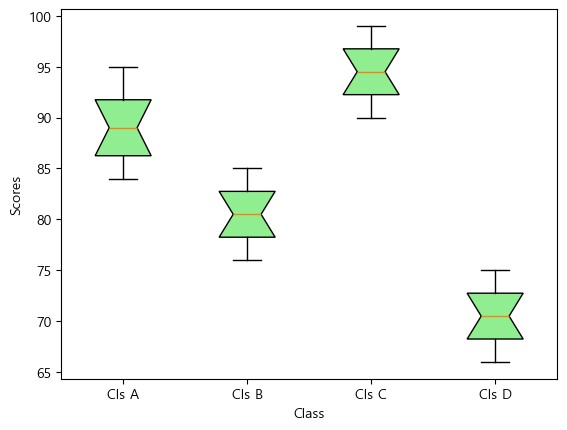

In [37]:
# DataFrame에서 작성하기
class_scores_df = pd.DataFrame({
    "ClassA":[85, 88, 90, 92, 93, 87, 95, 91, 84, 86],  # Class A
    "ClassB":[78, 82, 85, 80, 79, 84, 81, 83, 77, 76],  # Class B
    "ClassC":[92, 95, 96, 94, 90, 97, 93, 91, 98, 99],  # Class C
    "ClassD":[70, 72, 68, 75, 74, 69, 73, 71, 66, 67]   # Class D
})

plt.boxplot(class_scores_df.values,
            notch=True,
            patch_artist=True,
            boxprops=dict(facecolor='lightgreen'))

plt.xlabel('Class')
plt.ylabel('Scores')

# ticks
plt.xticks([1, 2, 3, 4], ['Cls A', 'Cls B', 'Cls C', 'Cls D'])

plt.show()

In [38]:
# 사분위수 도출
class_scores_df.describe()

,ClassA,ClassB,ClassC,ClassD
count,10.000000,10.00000,10.00000,10.00000
mean,89.100000,80.50000,94.50000,70.50000
std,3.665151,3.02765,3.02765,3.02765
min,84.000000,76.00000,90.00000,66.00000
25%,86.250000,78.25000,92.25000,68.25000
50%,89.000000,80.50000,94.50000,70.50000
75%,91.750000,82.75000,96.75000,72.75000
max,95.000000,85.00000,99.00000,75.00000


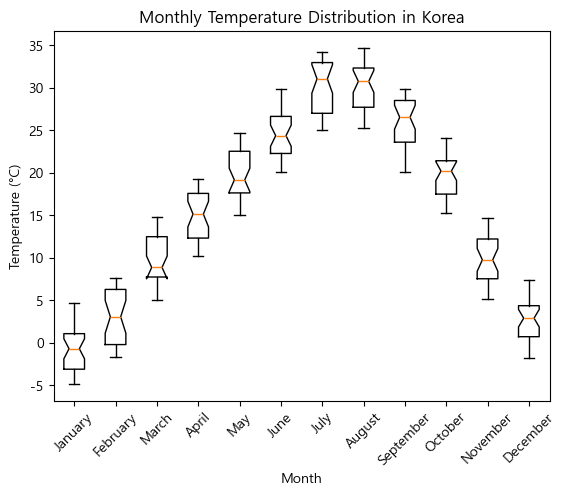

In [39]:
# 월별 기온 데이터
np.random.seed(42) # 관례적인 seed값

temperatures = [
    # np.random.uniform(최소값, 최대값, 개수)
    np.random.uniform(-5, 5, 31),    # January (31일)
    np.random.uniform(-2, 8, 28),    # February (28일)
    np.random.uniform(5, 15, 31),    # March (31일)
    np.random.uniform(10, 20, 30),   # April (30일)
    np.random.uniform(15, 25, 31),   # May (31일)
    np.random.uniform(20, 30, 30),   # June (30일)
    np.random.uniform(25, 35, 31),   # July (31일)
    np.random.uniform(25, 35, 31),   # August (31일)
    np.random.uniform(20, 30, 30),   # September (30일)
    np.random.uniform(15, 25, 31),   # October (31일)
    np.random.uniform(5, 15, 30),    # November (30일)
    np.random.uniform(-2, 8, 31)     # December (31일)
]

plt.boxplot(temperatures, notch=True)

# X축에 월 추가
plt.xticks([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
           ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'],
           rotation=45)

# 레이블 및 타이틀 추가
plt.xlabel('Month')
plt.ylabel('Temperature (°C)')
plt.title('Monthly Temperature Distribution in Korea')

plt.show()

### 이상치 표시하기
Box Plot은 데이터의 이상치(outlier)를 자동으로 감지하여 표시한다.
이상치는 수염(whisker) 바깥쪽에 있는 값으로, 박스 바깥에 작은 점으로 표시된다.

이상치(Outlier)는 보통 데이터의 분포에서 크게 벗어난 값들을 말하며, Boxplot에서 이상치를 판별하는 기준은 일반적으로 **IQR(Interquartile Range, 사분위수 범위)** 를 기반으로 한다.

**Boxplot 구성 요소 요약:**
```txt
      ○  이상치 (outlier)

      |------ whisker top (최댓값 또는 이상치 전까지)
      |       
 Q3 ──┐────┐  ← 3사분위수 (75%)
      │    │
      │    │
      │    │
 Q2 ──┼────┘  ← 중앙값 (50%)
      │    │
      │    │
 Q1 ──┘────┘  ← 1사분위수 (25%)
      |
      |------ whisker bottom (최솟값 또는 이상치 전까지)
             
```

**핵심 설명:**
* Q1 (1사분위수): 하위 25% 지점
* Q2 (중앙값, Median): 50% 지점
* Q3 (3사분위수): 상위 75% 지점
* IQR (Interquartile Range): Q3 - Q1
* Whisker (수염):
    * 이상치가 없을 경우 최솟값과 최댓값,
    * 이상치가 있을 경우 Q1 - 1.5×IQR ~ Q3 + 1.5×IQR 범위 내의 값


**이상치 판별**
위에서 구한 하한선보다 작은 값이나 상한선보다 큰 값들을 이상치로 간주한다.


**이상치가 있는 경우:**
* 맨 아랫값 (whisker bottom): Q1 - 1.5×IQR 이상인 값 중 최소값
* 맨 윗값 (whisker top): Q3 + 1.5×IQR 이하인 값 중 최댓값
* 그보다 바깥에 있는 값들은 ○ 같은 점으로 **이상치(outlier)** 로 표시됨


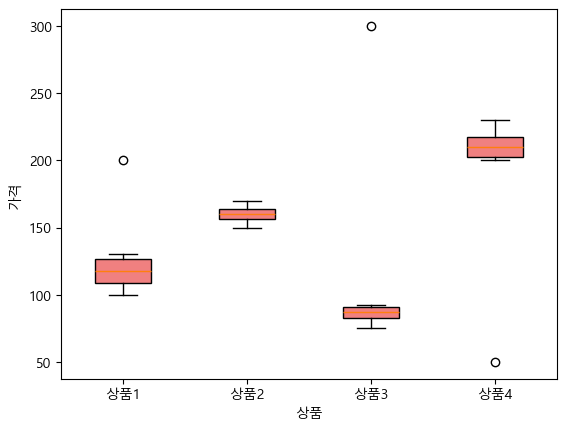

In [40]:
# 이상치가 포함된 데이터
data_with_outliers = [
    [100, 120, 130, 110, 115, 105, 125, 200],   # 이상치 200 포함
    [150, 160, 170, 155, 165, 158, 162],
    [80, 85, 90, 75, 92, 87, 300],              # 이상치 300 포함
    [200, 220, 210, 205, 215, 230, 50],         # 이상치 50 포함
]

plt.boxplot(data_with_outliers, patch_artist=True, boxprops=dict(facecolor='lightcoral'))

plt.xticks([1, 2, 3, 4], ['상품1', '상품2', '상품3', '상품4'])

plt.xlabel('상품')
plt.ylabel('가격')

plt.show()


In [41]:
# IQR 계산
data = np.array(data_with_outliers[0])
data

# np.quantile(데이터, quantile) : 데이터에서 quantile에 해당하는 값 계산
q3 = np.quantile(data, 0.75)    
q1 = np.quantile(data, 0.25)
iqr = q3 - q1

print('q1 =', q1)
print('q3 =', q3)
print('iqr =', iqr)

# 위/아래 경계
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
print('lower bound =', lower_bound)
print('upper bound =', upper_bound)

# 이상치 검출
outliers = data[(data < lower_bound) | (data > upper_bound)]
outliers

q1 = 108.75
q3 = 126.25
iqr = 17.5
lower bound = 82.5
upper bound = 152.5


array([200])

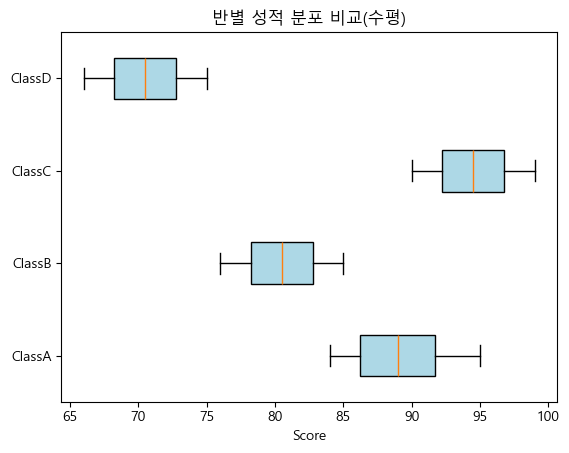

In [43]:
# TODO - Box Plot
# class_scores_df를 이용해 '수평' 박스플롯을 그려보세요.
# 조건: 1) vert=False 옵션 사용 2) 박스 채우기 색상을 'lightblue'로 설정
#      3) 어떤 반의 성적 분포(박스 길이)가 가장 넓은지 주석으로 적기
plt.boxplot(class_scores_df.values,
            vert=False,
            patch_artist=True,
            boxprops=dict(facecolor='lightblue'))
plt.yticks([1,2,3,4],class_scores_df.columns)
plt.title('반별 성적 분포 비교(수평)')
plt.xlabel('Score')
plt.show()

## 정리
- Histogram: 연속형 데이터 분포
- Bar Plot: 범주 비교
- Line Plot: 추이 변화
- Scatter Plot: 두 변수 관계
- Pie Chart: 비율 / 점유율
- Box Plot: 분포 + 이상치

그래프는 '예쁘게 그리는 것'보다 '왜 이 차트를 골랐는가'가 더 중요하다.